# Baseline Model - ResNet50

## Overview
This notebook trains a ResNet50 model with transfer learning as the baseline 
for brain tumor classification across 4 classes: glioma, meningioma, 
notumor and pituitary.

## Approach
- Pretrained ResNet50 (ImageNet weights)
- All layers frozen except the final classifier
- Trained for 10 epochs with Adam optimizer (lr=0.001)
- Standard data augmentation (flip, rotation)

## Why ResNet50?
ResNet50 is a well-established architecture for image classification with 
strong transfer learning performance, making it a reliable baseline choice.

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
train_dir = "/content/drive/MyDrive/brain-tumor-data/Training"
test_dir = "/content/drive/MyDrive/brain-tumor-data/Testing"

classes = ["glioma", "meningioma", "notumor", "pituitary"]
num_classes = len(classes)
class_to_idx = {cls: i for i, cls in enumerate(classes)}

# Parameters
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)  
print("Classes:", class_to_idx)

Using device: cuda
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [18]:
class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        
        for cls in classes:
            cls_path = os.path.join(root_dir, cls)
            for img_file in os.listdir(cls_path):
                self.images.append(os.path.join(cls_path, img_file))
                self.labels.append(class_to_idx[cls])
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [19]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = BrainTumorDataset(train_dir, transform=train_transform)
test_dataset = BrainTumorDataset(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Training samples: 5600
Testing samples: 1600


## Training
Training only the final classifier layer while keeping all pretrained 
ImageNet features frozen.

In [6]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)


# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer for our 4 classes
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)
print(model.fc)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


Linear(in_features=2048, out_features=4, bias=True)


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

In [8]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {running_loss/len(train_loader):.4f} Accuracy: {acc:.2f}%")

Epoch [1/10] Loss: 0.6468 Accuracy: 76.52%
Epoch [2/10] Loss: 0.4657 Accuracy: 82.55%
Epoch [3/10] Loss: 0.3852 Accuracy: 86.02%
Epoch [4/10] Loss: 0.3739 Accuracy: 86.14%
Epoch [5/10] Loss: 0.3673 Accuracy: 86.25%
Epoch [6/10] Loss: 0.3235 Accuracy: 88.04%
Epoch [7/10] Loss: 0.3299 Accuracy: 88.02%
Epoch [8/10] Loss: 0.3089 Accuracy: 88.23%
Epoch [9/10] Loss: 0.3141 Accuracy: 88.45%
Epoch [10/10] Loss: 0.3078 Accuracy: 88.55%


In [9]:
torch.save(model.state_dict(), "/content/drive/MyDrive/brain-tumor-data/brain_tumor_resnet50.pth")
print("Model saved to Google Drive!")

Model saved to Google Drive!


## Evaluation on Test Set
Evaluating the baseline model on 1600 unseen test images.

**Results:** 85.75% test accuracy. Confusion matrix analysis revealed that 
glioma and meningioma are frequently confused, while notumor and pituitary 
are classified almost perfectly.

In [10]:
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 85.75%


## Confusion Matrix
Visualizing which classes the model confuses most often.

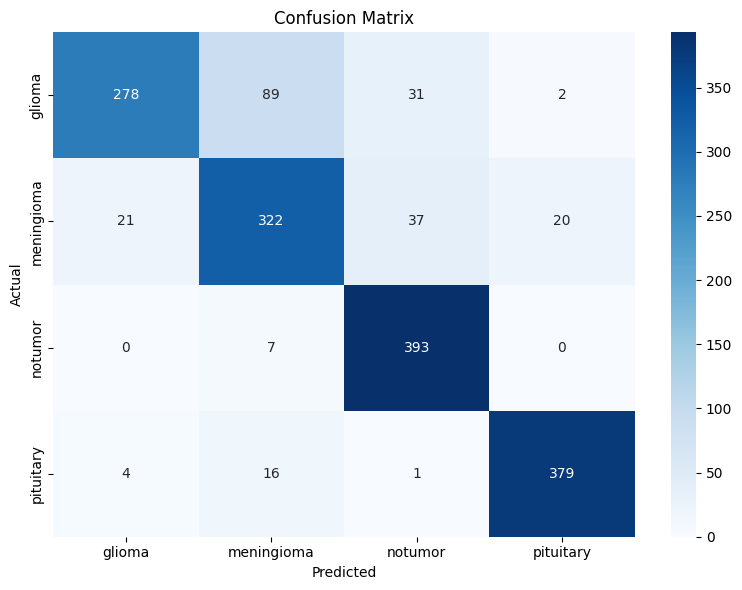

In [11]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/brain-tumor-data/confusion_matrix.png")
plt.show()

In [12]:
print(classification_report(all_labels, all_preds, target_names=classes))

              precision    recall  f1-score   support

      glioma       0.92      0.69      0.79       400
  meningioma       0.74      0.81      0.77       400
     notumor       0.85      0.98      0.91       400
   pituitary       0.95      0.95      0.95       400

    accuracy                           0.86      1600
   macro avg       0.86      0.86      0.86      1600
weighted avg       0.86      0.86      0.86      1600



## Fine-tuning ResNet50

Based on the Grad-CAM analysis in `03_gradcam.ipynb`, the baseline model showed 
shortcut behavior — focusing on skull edges and background rather than tumor tissue 
for glioma and meningioma. 

To address this, we unfreeze the last residual block (layer4) and retrain with 
a lower learning rate (1e-4), allowing the model to learn MRI-specific features 
instead of relying solely on frozen ImageNet features.

**Result:** Test accuracy improved from 85.75% → 94.19%, with the biggest 
gains in meningioma (80.5% → 99%) and pituitary (94.8% → 100%).

In [14]:
# Load fine-tuned model (skip training if already saved)
finetuned_model = models.resnet50(weights=None)
finetuned_model.fc = nn.Linear(finetuned_model.fc.in_features, num_classes)
finetuned_model.load_state_dict(torch.load("/content/drive/MyDrive/brain-tumor-data/resnet50_finetuned.pth", map_location=device))
finetuned_model = finetuned_model.to(device)
finetuned_model.eval()
print("Fine-tuned model loaded!")

Fine-tuned model loaded!


In [10]:
#Fine tuning
# First freeze ALL layers
for param in finetuned_model.parameters():
    param.requires_grad = False

# Then unfreeze layer4 and final classifier
for param in finetuned_model.layer4.parameters():
    param.requires_grad = True

for param in finetuned_model.fc.parameters():
    param.requires_grad = True

# Check
trainable = sum(p.numel() for p in finetuned_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in finetuned_model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}")

Trainable parameters: 14,972,932 / 23,516,228


In [11]:
# Use a lower learning rate for fine-tuning
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, finetuned_model.parameters()),
    lr=0.0001  # 10x lower than original 0.001
)

print("=== Fine-tuning ResNet50 ===")
for epoch in range(EPOCHS):
    finetuned_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = finetuned_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {running_loss/len(train_loader):.4f} Accuracy: {acc:.2f}%")

torch.save(finetuned_model.state_dict(), "/content/drive/MyDrive/brain-tumor-data/resnet50_finetuned.pth")
print("Fine-tuned model saved!")

=== Fine-tuning ResNet50 ===
Epoch [1/10] Loss: 0.2418 Accuracy: 91.38%
Epoch [2/10] Loss: 0.1113 Accuracy: 96.09%
Epoch [3/10] Loss: 0.0697 Accuracy: 97.57%
Epoch [4/10] Loss: 0.0616 Accuracy: 98.04%
Epoch [5/10] Loss: 0.0309 Accuracy: 98.84%
Epoch [6/10] Loss: 0.0310 Accuracy: 98.88%
Epoch [7/10] Loss: 0.0494 Accuracy: 98.59%
Epoch [8/10] Loss: 0.0320 Accuracy: 98.98%
Epoch [9/10] Loss: 0.0208 Accuracy: 99.27%
Epoch [10/10] Loss: 0.0301 Accuracy: 99.05%
Fine-tuned model saved!


In [20]:
finetuned_model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = finetuned_model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f"Fine-tuned Test Accuracy: {accuracy:.2f}%")
print(classification_report(all_labels, all_preds, target_names=classes))

Fine-tuned Test Accuracy: 94.19%
              precision    recall  f1-score   support

      glioma       1.00      0.79      0.88       400
  meningioma       0.88      0.99      0.93       400
     notumor       0.92      0.99      0.95       400
   pituitary       0.99      1.00      1.00       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600



## Fine-tuned Model - Confusion Matrix
Comparing confusion matrix before and after fine-tuning to visualize the improvement.

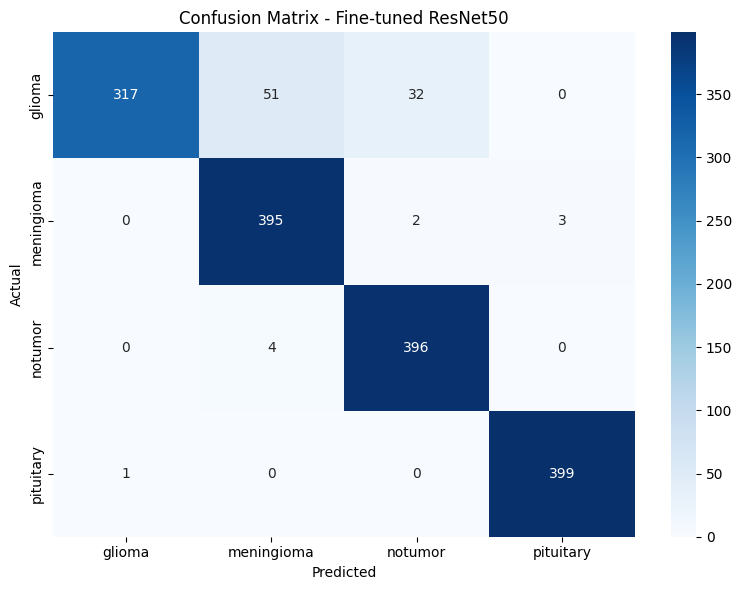

In [21]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Fine-tuned ResNet50")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/brain-tumor-data/confusion_matrix_finetuned.png")
plt.show()